Dataset already downloaded.
Found 701 images and 701 masks.
Epoch 1, Loss: 2.1630
Epoch 2, Loss: 1.3669
Epoch 3, Loss: 1.0620
Epoch 4, Loss: 0.8838
Epoch 5, Loss: 0.7878


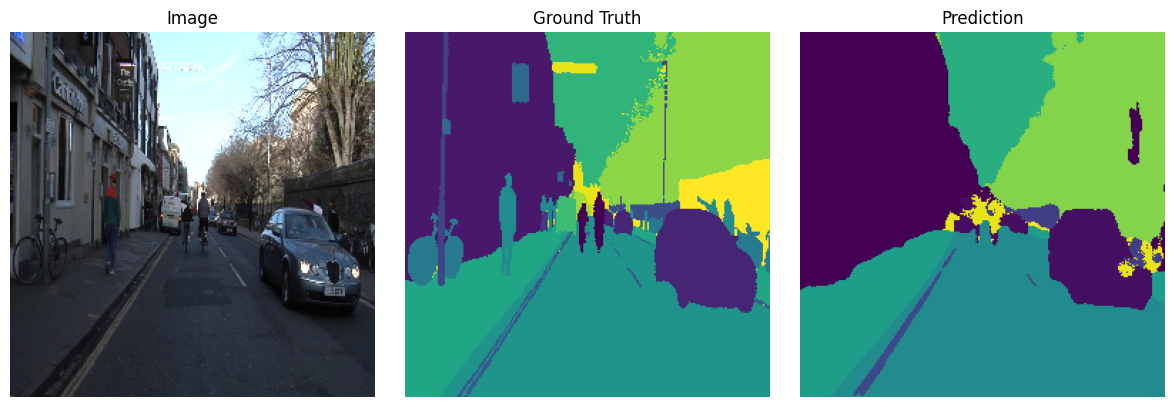

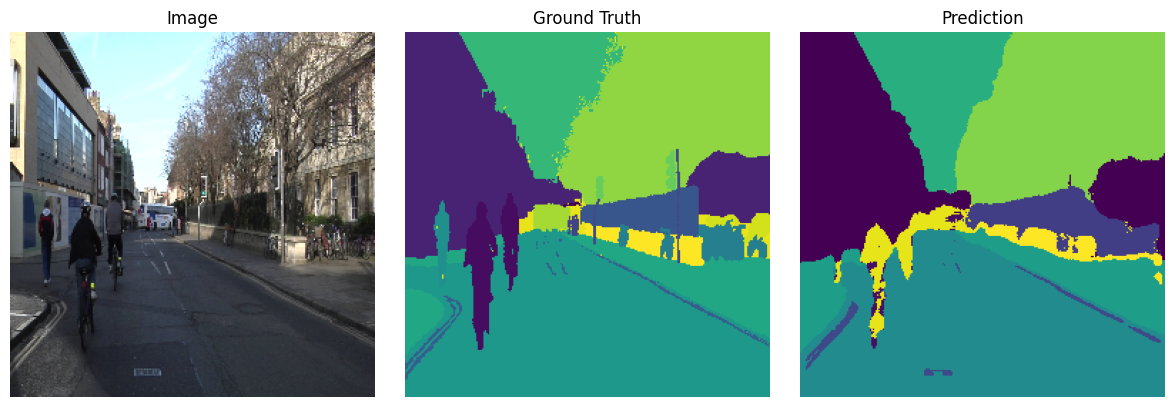

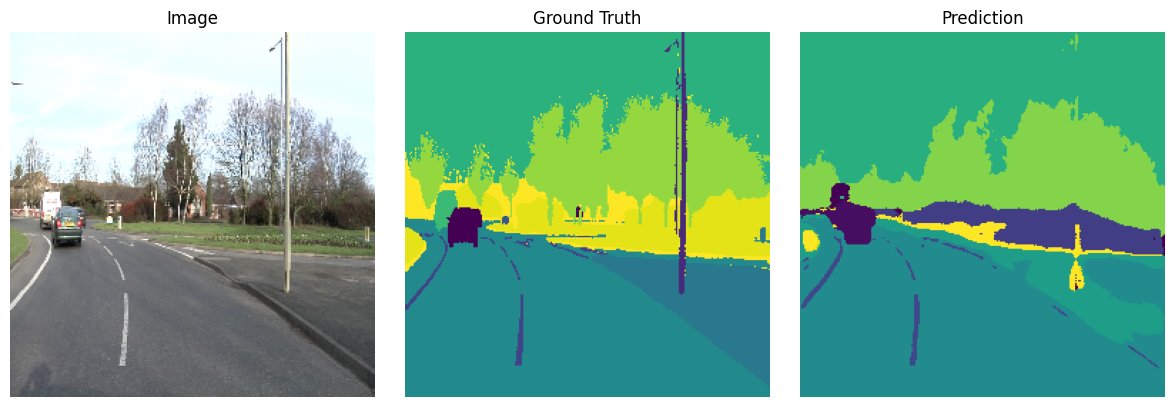

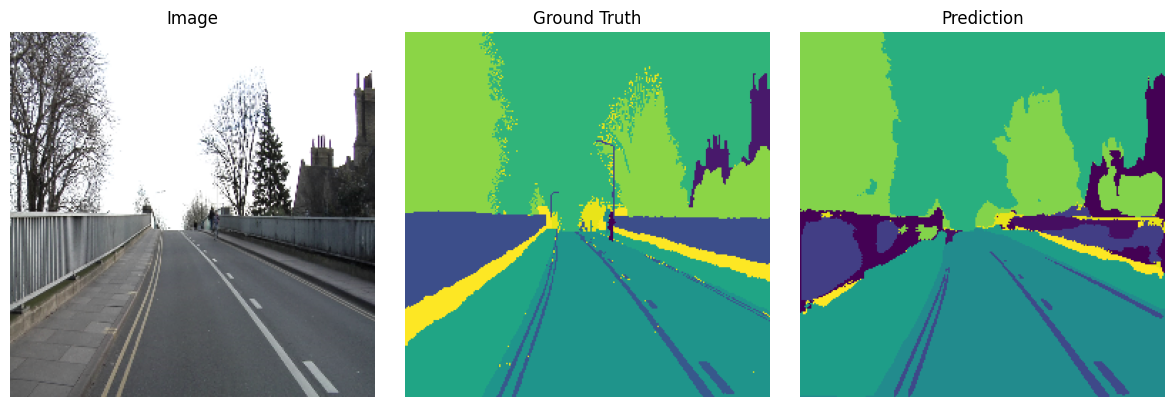

: 

In [ ]:
import os
import numpy as np
import cv2
from glob import glob
import zipfile
import requests
import shutil
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt

# -------------------------
# Download and Extract CamVid Dataset
# -------------------------
dataset_url = "https://s3.amazonaws.com/fast-ai-imagelocal/camvid.tgz"
dataset_dir = "CamVid"

def download_and_extract_dataset(url, extract_to):
    tgz_path = "camvid.tgz"
    if not os.path.exists(extract_to):
        print("Downloading CamVid dataset...")
        r = requests.get(url, stream=True)
        with open(tgz_path, 'wb') as f:
            shutil.copyfileobj(r.raw, f)

        print("Extracting CamVid dataset...")
        shutil.unpack_archive(tgz_path, extract_to)
        os.remove(tgz_path)
        print("Dataset ready!")
    else:
        print("Dataset already downloaded.")

# Run download
download_and_extract_dataset(dataset_url, dataset_dir)

# -------------------------
# U-Net Model
# -------------------------
class UNet(nn.Module):
    def __init__(self, num_classes):
        super(UNet, self).__init__()

        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = CBR(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = CBR(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = CBR(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = CBR(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = CBR(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

# -------------------------
# Dataset Class
# -------------------------
class CamVidDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))

        mask = cv2.imread(self.mask_paths[idx], 0)  # grayscale
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            image = self.transform(image)

        mask = torch.from_numpy(mask).long()
        return image, mask

# -------------------------
# Data Preparation
# -------------------------
image_paths = sorted(glob(os.path.join(dataset_dir, "camvid", "images", "*.png")))
mask_paths = sorted(glob(os.path.join(dataset_dir, "camvid", "labels", "*.png")))


transform = T.Compose([T.ToTensor()])
dataset = CamVidDataset(image_paths, mask_paths, transform=transform)
print(f"Found {len(image_paths)} images and {len(mask_paths)} masks.")

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# -------------------------
# Training Loop
# -------------------------
model = UNet(num_classes=32).cuda()  # 32 classes for CamVid
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    epoch_loss = 0
    for imgs, masks in dataloader:
        imgs, masks = imgs.cuda(), masks.cuda()
        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(dataloader):.4f}")

# -------------------------
# Visualize Predictions
# -------------------------
model.eval()
imgs, masks = next(iter(dataloader))
imgs = imgs.cuda()
with torch.no_grad():
    preds = torch.argmax(model(imgs), dim=1).cpu()

for i in range(4):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(imgs[i].permute(1, 2, 0).cpu())
    axs[0].set_title("Image")
    axs[1].imshow(masks[i])
    axs[1].set_title("Ground Truth")
    axs[2].imshow(preds[i])
    axs[2].set_title("Prediction")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
